In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. Veri setini yükleme
file_path = "data/lip_coordinates.csv"
df = pd.read_csv(file_path)

# 2. İlk birkaç satırı görüntüleme
print(df.head())

# 3. Eksik veri kontrolü
missing_values = df.isnull().sum().sum()
print(f"Eksik Değer Sayısı: {missing_values}")

# 4. Zaman serisi indeksini ayarlama
df.set_index("time", inplace=True)

# 5. Veri tiplerini kontrol etme
print(df.info())

   time  0_x  13_x  14_x  17_x  37_x  39_x  40_x  61_x  78_x  ...  314_y  \
0  0.00  637   637   637   637   628   619   613   607   611  ...    331   
1  0.04  638   638   638   639   629   620   614   607   611  ...    330   
2  0.08  638   638   639   639   629   620   614   607   611  ...    330   
3  0.12  638   638   638   639   629   620   614   607   611  ...    330   
4  0.16  638   638   638   639   629   619   613   607   610  ...    330   

   317_y  318_y  321_y  324_y  375_y  402_y  405_y  409_y  415_y  
0    319    318    325    319    322    318    328    317    318  
1    318    318    324    318    321    318    327    316    317  
2    318    317    324    317    321    318    327    316    316  
3    318    317    323    317    321    317    327    316    316  
4    317    317    323    317    320    317    327    315    316  

[5 rows x 81 columns]
Eksik Değer Sayısı: 0
<class 'pandas.core.frame.DataFrame'>
Index: 1099 entries, 0.0 to 43.92
Data columns (total 80 c

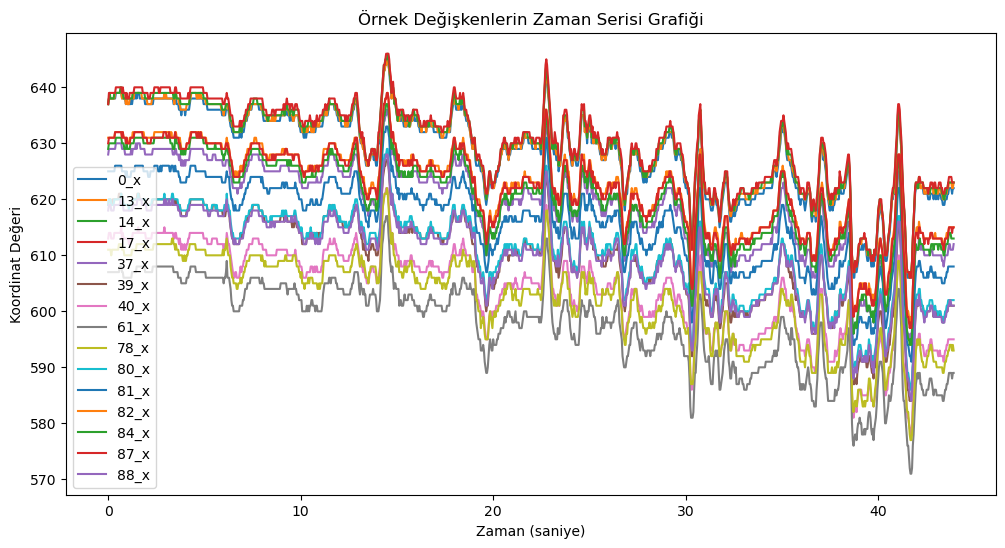

In [2]:
# 6. Örnek değişkenlerin zaman serisi grafiğini çizme
sample_columns = df.columns[:15]
plt.figure(figsize=(12, 6))
for col in sample_columns:
    plt.plot(df.index, df[col], label=col)
plt.xlabel("Zaman (saniye)")
plt.ylabel("Koordinat Değeri")
plt.title("Örnek Değişkenlerin Zaman Serisi Grafiği")
plt.legend()
plt.show()

In [3]:
# 7. ADF testi ile durağanlık analizi
adf_results = {}
for col in df.columns[:15]:  # İlk 5 değişken için
    adf_test = adfuller(df[col])
    adf_results[col] = {"ADF Statistic": adf_test[0], "p-value": adf_test[1]}

# 8. Sonuçları tablo olarak gösterme
adf_df = pd.DataFrame(adf_results).T
print(adf_df)

      ADF Statistic   p-value
0_x       -2.164544  0.219365
13_x      -2.203439  0.205000
14_x      -2.171966  0.216577
17_x      -2.247038  0.189618
37_x      -2.198147  0.206919
39_x      -2.065875  0.258456
40_x      -1.931358  0.317456
61_x      -2.014732  0.280151
78_x      -1.940720  0.313154
80_x      -1.783891  0.388488
81_x      -2.033165  0.272223
82_x      -2.054777  0.263083
84_x      -2.208938  0.203018
87_x      -2.240129  0.192005
88_x      -1.913254  0.325852


In [7]:
# 9. Durağan olmayan seriler için fark alma (birinci derece fark)
df_diff = df.diff().dropna()

# 10. Yeniden ADF testi uygulama
diff_adf_results = {}
for col in df_diff.columns[:15]:
    adf_test = adfuller(df_diff[col])
    diff_adf_results[col] = {"ADF Statistic": adf_test[0], "p-value": adf_test[1]}

diff_adf_df = pd.DataFrame(diff_adf_results).T
print("Fark alınmış seriler için ADF Test Sonuçları:")
print(diff_adf_df)

Fark alınmış seriler için ADF Test Sonuçları:
      ADF Statistic       p-value
0_x      -11.978892  3.745101e-22
13_x     -10.839581  1.628850e-19
14_x     -12.067360  2.391519e-22
17_x     -12.451625  3.564806e-23
37_x     -11.951368  4.309180e-22
39_x     -12.040541  2.738762e-22
40_x     -12.502882  2.781349e-23
61_x     -12.423750  4.082269e-23
78_x     -12.161226  1.492070e-22
80_x     -10.512292  1.017138e-18
81_x     -11.991126  3.519096e-22
82_x     -12.040790  2.735304e-22
84_x     -12.086306  2.173559e-22
87_x     -11.975153  3.817080e-22
88_x     -11.617477  2.429233e-21


In [9]:
# 11. Gecikme uzunluğunu belirleme
from statsmodels.tsa.api import VAR
model = VAR(df_diff)
lag_selection = model.select_order(maxlags=5)  # Selects optimal lag order from 1 to 15 lags
print("Gecikme Uzunluğu Seçimi:")
print(lag_selection.summary())

# 12. VAR modeli eğitme
optimal_lag = lag_selection.aic  # You can also use other criteria like 'bic' or 'fpe' based on your preference
var_result = model.fit(optimal_lag)
print(var_result.summary())

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Gecikme Uzunluğu Seçimi:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -129.7     -129.4*   4.616e-57      -129.6
1      -145.8      -116.2   4.710e-64     -134.6*
2      -149.5      -90.58   1.454e-65      -127.2
3      -150.0      -61.89  1.254e-65*      -116.7
4      -150.0      -32.64   2.870e-65      -105.6
5     -150.3*      -3.653   9.298e-65      -94.81
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 12, Mar, 2025
Time:                     08:47:29
--------------------------------------------------------------------
No. of Equations:         80.0000    BIC:                   -3.65283
Nobs:                     1093.00    HQIC:                  -94.8096
Log likelihood:          -9848.94    FPE:                9.29829e-65
AIC:                    

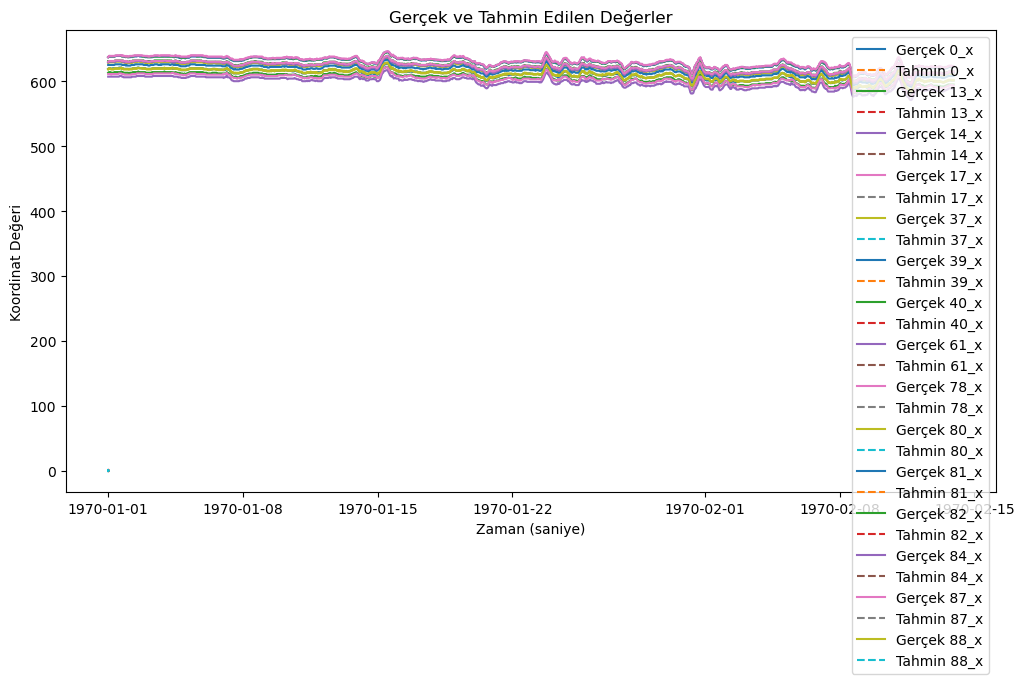

In [18]:
# 13. Modelin tahmin performansını değerlendirme
lag_order = var_result.k_ar
y_pred = var_result.forecast(df_diff.values[-lag_order:], steps=10)
forecast_index = pd.date_range(start=df.index[-1], periods=10, freq='s')
y_pred_df = pd.DataFrame(y_pred, index=forecast_index, columns=df_diff.columns)

# 14. Tahmin sonuçlarını görselleştirme
plt.figure(figsize=(12, 6))
for col in sample_columns:
    plt.plot(df.index, df[col], label=f"Gerçek {col}")
    plt.plot(y_pred_df.index, y_pred_df[col], linestyle='dashed', label=f"Tahmin {col}")
plt.xlabel("Zaman (saniye)")
plt.ylabel("Koordinat Değeri")
plt.title("Gerçek ve Tahmin Edilen Değerler")
plt.legend()
plt.show()